# 07 — L'ADE : un filtre qui dissipe l'entropie au lieu de l'accumuler

Un algorithme de recommandation classique maximise l'engagement immédiat. Le
notebook 06 montre que cette fonction de coût *est* celle qui produit un
amortissement négatif : elle récompense la charge émotionnelle, donc la
désinformation.

L'**Algorithme de Diversité Exposée** remplace la fonction de coût :

$$S(i, c) = \mathrm{Pertinence}(i, c) + \mu \cdot \Delta H(i, c)$$

où $\Delta H$ mesure ce que l'affichage du contenu ferait à l'IDE du fil, et
$\mu \ge 0$ est le coefficient de régulation.

Deux précisions valent d'être faites d'emblée. Le **signe est positif** : le fil de
travail hésitait, mais seul $+\mu \Delta H$ fait remonter un contenu qui diversifie.
Et le terme de pertinence est **conservé** : un algorithme qui servirait de la
diversité sans pertinence serait abandonné par ses utilisateurs, ce qui ne
dissiperait aucune entropie. L'ADE n'est pas un filtre de censure, c'est un
rééquilibrage.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.ade import Candidate, EntropicScorer, annealing_coefficient
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()

CATALOGUE = [
    Candidate("contenu-de-bulle", "complot", relevance=0.95),
    Candidate("verification", "factuel", relevance=0.50),
    Candidate("tribune", "opinion", relevance=0.45),
    Candidate("satire", "satire", relevance=0.40),
]
frozen_feed = ["complot"] * 20

scorer = EntropicScorer(catalogue_size=4)
for scored in scorer.rank(frozen_feed, CATALOGUE):
    print(f"{scored.identifier:18s} pertinence={scored.candidate.relevance:.2f} "
          f"ΔH={scored.delta_entropy:+.3f}  μ={scored.mu:.2f}  score={scored.score:.3f}")

verification       pertinence=0.50 ΔH=+0.138  μ=4.00  score=1.052
tribune            pertinence=0.45 ΔH=+0.138  μ=4.00  score=1.002
satire             pertinence=0.40 ΔH=+0.138  μ=4.00  score=0.952
contenu-de-bulle   pertinence=0.95 ΔH=+0.000  μ=4.00  score=0.950


## Le recuit : $\mu$ n'est pas constant

Tant que le fil reste diversifié, l'algorithme n'a aucune raison d'intervenir et
$\mu$ demeure à sa valeur de repos. Dès que l'IDE passe sous le seuil critique —
signal d'une bulle qui se referme — $\mu$ monte et l'algorithme entre en **mode
recuit** : il sur-classe délibérément les contenus divergents, le temps de réchauffer
le fil.

La montée est **progressive** et non en tout ou rien. Avec un seuil dur, chaque
intervention relèverait l'index juste au-dessus du seuil, désactivant l'intervention
suivante, qui le laisserait retomber : un battement permanent sans stabilisation.

In [2]:
indices = np.linspace(0.0, 1.0, 201)
coefficients = np.array([annealing_coefficient(float(i), critical_index=0.4) for i in indices])

def serve_loop(mu_resting: float, mu_annealing: float, cycles: int = 40) -> np.ndarray:
    """Sert `cycles` contenus et renvoie la trajectoire de l'IDE du fil."""
    engine = EntropicScorer(catalogue_size=4, resting_mu=mu_resting, annealing_mu=mu_annealing)
    feed = list(frozen_feed)
    history = [engine.current_index(feed)]
    for _ in range(cycles):
        feed = engine.serve(feed, CATALOGUE)
        history.append(engine.current_index(feed))
    return np.array(history)

engagement_only = serve_loop(0.0, 0.0)
with_annealing = serve_loop(0.5, 4.0)

print(f"filtre d'engagement pur : IDE final = {engagement_only[-1]:.3f}")
print(f"ADE avec recuit         : IDE final = {with_annealing[-1]:.3f}")

filtre d'engagement pur : IDE final = 0.000
ADE avec recuit         : IDE final = 0.061


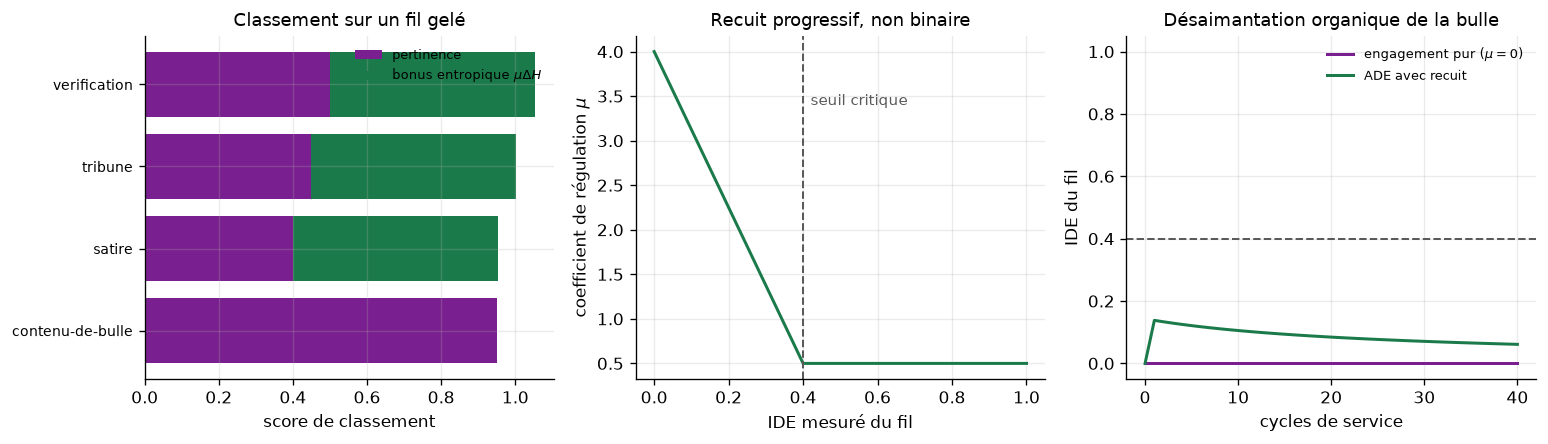

In [3]:
figure, axes = plt.subplots(1, 3, figsize=(13, 3.8))
scores, annealing, trajectory = axes

ranked = scorer.rank(frozen_feed, CATALOGUE)
positions = np.arange(len(ranked))
labels = [scored.identifier for scored in ranked]
relevances = [scored.candidate.relevance for scored in ranked]
bonuses = [scored.mu * scored.delta_entropy for scored in ranked]

scores.barh(positions, relevances, color=PALETTE["field"], label="pertinence")
scores.barh(positions, bonuses, left=relevances, color=PALETTE["remedy"],
            label=r"bonus entropique $\mu \Delta H$")
scores.set_yticks(positions)
scores.set_yticklabels(labels, fontsize=8.5)
scores.invert_yaxis()
scores.set_xlabel("score de classement")
scores.set_title("Classement sur un fil gelé")
scores.legend(fontsize=8)

annealing.plot(indices, coefficients, color=PALETTE["remedy"])
annealing.axvline(0.4, color=PALETTE["neutral"], linestyle="--", linewidth=1.2)
annealing.text(0.42, 3.4, "seuil critique", color=PALETTE["neutral"], fontsize=9)
annealing.set_xlabel("IDE mesuré du fil")
annealing.set_ylabel(r"coefficient de régulation $\mu$")
annealing.set_title("Recuit progressif, non binaire")

trajectory.plot(engagement_only, color=PALETTE["field"], label="engagement pur ($\\mu = 0$)")
trajectory.plot(with_annealing, color=PALETTE["remedy"], label="ADE avec recuit")
trajectory.axhline(0.4, color=PALETTE["neutral"], linestyle="--", linewidth=1.2)
trajectory.set_xlabel("cycles de service")
trajectory.set_ylabel("IDE du fil")
trajectory.set_ylim(-0.05, 1.05)
trajectory.set_title("Désaimantation organique de la bulle")
trajectory.legend(fontsize=8)

save_figure(figure, "fig07_ade.png")
plt.show()

## Ce que le notebook établit

1. Sur un fil gelé, la vérification factuelle dépasse au classement un contenu
   pourtant bien plus pertinent — non par pénalisation du second, mais par bonus
   entropique du premier.
2. À $\mu = 0$, l'ADE est **indiscernable** d'un filtre d'engagement : la
   transformation est un ajout paramétré, pas une refonte. C'est ce qui la rend
   déployable et auditable — un régulateur peut exiger une valeur minimale de $\mu$
   sans redéfinir le produit.
3. Le mode recuit fait effectivement remonter l'IDE d'un fil initialement gelé,
   alors que le filtre d'engagement pur l'y maintient indéfiniment.
4. Une fois l'index rétabli, $\mu$ redescend à sa valeur de repos et la pertinence
   reprend la main. L'algorithme n'impose pas la diversité en permanence : il empêche
   le gel.